# Problema 1


Tomamos los modelos base de las clases, a los cuales añadimos una función evalP, la cual nos permite evaluar la probabilidad de observar una imagen $p(x)$, además de una función de entrenamiento.

Cargamos MNIST y creamos los loaders de entrenamiento y prueba

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as tt
import torch.nn.functional as F
import torch.distributions as td
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

In [2]:
transform=transforms.Compose([
    transforms.ToTensor(),
])
dataset_train = datasets.MNIST('data/', train=True, download=True,transform=transform)
dataset_test = datasets.MNIST('data/', train=False, transform=transform)
training_loader = torch.utils.data.DataLoader(dataset_train,batch_size=1024)
testing_loader = torch.utils.data.DataLoader(dataset_test,batch_size=1024)

Iniciamos con la mezcla de Gaussianas

In [3]:
class LowerTriangularPositive(nn.Module):

    def __init__(self, K, D):
        super().__init__()
        # Diagonal terms initialized at one
        diags = torch.diag(torch.ones((D))).repeat(K,1,1)
        outdiags = 0.01*torch.randn(K, D, D)
        self.tril = nn.Parameter(diags+outdiags)
        self.register_buffer('mask', torch.tril(torch.ones(D, D), diagonal=-1))
        self.register_buffer('diag_mask', torch.diag(torch.ones(D)))

    def forward(self):
        L = torch.zeros_like(self.tril)
        for i in range(self.tril.shape[0]):
            L[i] = self.tril[i] * self.mask
            L[i] = L[i] + self.diag_mask * torch.sigmoid(self.tril[i].diag()).diag() # Ensure positive diagonal
        return L

In [4]:
class MoG(nn.Module):

    def __init__(self, D, K):
        super(MoG, self).__init__()
        # hyperparams
        self.D = D # the dimensionality of the input
        self.K = K # the number of components
        # params
        self.M = nn.Parameter(torch.sigmoid(torch.randn(self.K, self.D)))
        self.L = LowerTriangularPositive(self.K, self.D)
        self.pi = nn.Parameter(torch.zeros(1, self.K))

    def log_diag_normal(self, x, mu, L, reduction='sum', dim=1):
        m = td.MultivariateNormal(loc=mu,scale_tril=L)
        return m.log_prob(x)

    def forward(self, x):
        x = x.reshape(-1,1,self.D)
        # calculate components
        log_pi = torch.log(F.softmax(self.pi, 1)) # B x K
        log_N = torch.zeros(x.shape[0],self.K,device=x.device) # B x K
        Lt = self.L()
        for i in range(self.K):
            log_N[:,i:i+1] = self.log_diag_normal(x, torch.sigmoid(self.M[i]),Lt[i])
        NLL_loss = -torch.logsumexp(log_pi + log_N, 1) # B
        return NLL_loss.mean()

    def sample(self, batch_size=6):
        # init an empty tensor
        x_sample = torch.empty(batch_size, self.D)
        # First, sample components
        pi = F.softmax(self.pi, 1) # 1 x K, softmax is used for R^K -> [0,1]^K s.t. sum(pi) = 1
        indices = torch.multinomial(pi, batch_size, replacement=True).squeeze()
        # Then, sample the x given the component
        for n in range(batch_size):
            indx = torch.multinomial(pi, 1, replacement=True).squeeze()
            Lt = self.L()[indx]
            m = td.MultivariateNormal(loc=torch.sigmoid(self.M[indx]),scale_tril=Lt)
            x_sample[n] = m.rsample()
        return x_sample

    def evalP(self, x):
        x = x.reshape(-1,1,self.D)
        # calculate components
        log_pi = torch.log(F.softmax(self.pi, 1)) # B x K
        log_N = torch.zeros(x.shape[0],self.K,device=x.device) # B x K
        Lt = self.L()
        for i in range(self.K):
            log_N[:,i:i+1] = self.log_diag_normal(x, torch.sigmoid(self.M[i]),Lt[i])
        log_prob = torch.logsumexp(log_pi + log_N, 1) # B
        prob = torch.exp(log_prob)
        return prob.squeeze(), log_prob.squeeze()

Esta función de entrenamiento es la provista en las notas

In [5]:
def training(name, num_epochs, model, optimizer, training_loader):
    nll_min = 0
    # Main loop
    for e in range(num_epochs):
        # TRAINING
        model.train()
        for indx_batch, batch in enumerate(training_loader):
            x,y = batch
            x = x.to('cuda')
            loss = model.forward(x)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        print(f"{e:03d} {loss.detach().cpu().item():04.4f}")
        if e==0:
            nll_min = loss.item()
        if (loss.item()<nll_min):
            nll_min = loss.item()
            torch.save(model, name + '.model')

In [6]:
D = 784 # input dimension
K = 15 # the number of neurons in scale (s) and translation (t) nets
lr= 1e-4 # learning rate
num_epochs = 500 # max. number of epochs
name = 'mog'

In [7]:
# Eventually, we initialize the full model
model = MoG(D=D, K=K)
model = model.to("cuda")
# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [8]:
training(name, num_epochs, model, optimizer, training_loader)

000 537.7230
001 520.2741
002 512.1680
003 506.2144
004 501.3027
005 496.6802
006 491.1022
007 485.7516
008 481.8629
009 478.6417
010 475.7939
011 473.1896
012 470.7579
013 468.4548
014 466.2508
015 464.1253
016 462.0630
017 460.0523
018 458.0842
019 456.1516
020 454.2489
021 452.3713
022 450.5149
023 448.6766
024 446.8536
025 445.0435
026 443.2446
027 441.4549
028 439.6729
029 437.8976
030 436.1276
031 434.3619
032 432.5997
033 430.8402
034 429.0826
035 427.3262
036 425.5706
037 423.8151
038 422.0593
039 420.3027
040 418.5451
041 416.7859
042 415.0249
043 413.2618
044 411.4963
045 409.7283
046 407.9573
047 406.1833
048 404.4060
049 402.6254
050 400.8413
051 399.0534
052 397.2618
053 395.4663
054 393.6669
055 391.8634
056 390.0558
057 388.2441
058 386.4282
059 384.6080
060 382.7836
061 380.9550
062 379.1222
063 377.2851
064 375.4437
065 373.5980
066 371.7481
067 369.8939
068 368.0355
069 366.1726
070 364.3055
071 362.4340
072 360.5581
073 358.6777
074 356.7929
075 354.9036
076 353.0096

<ipython-input-9-4cfb2d55f9af>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_best = torch.load(name + '.model')


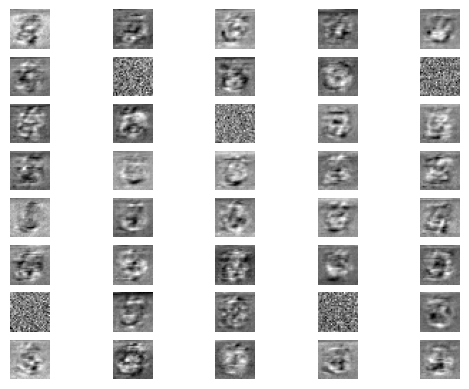

Mean p(x) on test set: inf


In [9]:
with torch.no_grad():
    model_best = torch.load(name + '.model')
    num_x = 8
    num_y = 5
    x = model_best.sample(batch_size=num_x * num_y)
    x = x.detach().numpy()
    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (28, 28))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.show()

    # Calculate p(x) for the test dataset using the trained model
    px_list = []
    for batch in testing_loader:
        x, _ = batch
        x = x.view(x.size(0), -1).to(model_best.M.device)  # Flatten and move to correct device
        px, _ = model_best.evalP(x)
        px_list.append(px.cpu())
    px_all = torch.cat(px_list)
    print(f"Mean p(x) on test set: {px_all.mean().item():.6f}")

In [10]:
# A very simple Sigmoid Belief Network (SBN) model
# This model uses a logistic regression-like approach
# to model the probability of binary variables.
class FullyVisibleSigmoidBeliefNetwork(torch.nn.Module):
    def __init__(self, input_size):
        super(FullyVisibleSigmoidBeliefNetwork, self).__init__()
        self.input_size = input_size
        self.register_buffer('autoregressive_mask', torch.tril(torch.ones(input_size, input_size), diagonal=-1))
        # Define the logistic regression weights and bias
        self.lr_weights = torch.nn.Parameter(torch.randn(input_size,input_size))
        self.lt_bias = torch.nn.Parameter(torch.randn(input_size))
        # Activation function
        self.sigmoid = nn.Sigmoid()
    # Forward pass of the model
    def forward(self, x):
        # We use a small epsilon to avoid log(0) issues
        # Forward pass evaluates the probability of an x given the alphas
        logits = nn.functional.linear(x,self.lr_weights*self.autoregressive_mask,self.lt_bias)
        return logits
    # Sample from the model
    def sample(self, num_samples):
        samples = torch.zeros(num_samples, self.input_size).to(self.lr_weights.device)
        probs = torch.zeros(num_samples, self.input_size).to(self.lr_weights.device)
        for i in range(self.input_size):
            prob = self.sigmoid(self.forward(samples))
            probs[:, i] = prob[:, i]
            # Sample from the Bernoulli distribution
            samples[:, i] = torch.bernoulli(prob[:, i])
        return samples,probs
    # Calculate p(x) and log p(x) for a given input x
    def evalP(self, x):
        """
        Evaluate the probability p(x) for a given input x.
        x: torch.Tensor of shape [input_size] or [1, input_size]
        Returns: probability p(x) and log-probability log p(x)
        """
        if x.ndim == 1:
            x = x.unsqueeze(0)
        logits = self.forward(x)
        prob_vec = torch.sigmoid(logits)
        # For binary data, p(x) = prod_i p_i^x_i * (1-p_i)^(1-x_i)
        p_x = torch.prod(prob_vec * x + (1 - prob_vec) * (1 - x), dim=1)
        log_p_x = torch.sum(x * torch.log(prob_vec + 1e-8) + (1 - x) * torch.log(1 - prob_vec + 1e-8), dim=1)
        return p_x.squeeze(), log_p_x.squeeze()

In [11]:
def train_models(name, num_epochs, model, optimizer, training_loader):
    min_loss = float('inf')
    for epoch in range(num_epochs):
        model.train()
        for batch_idx, (x, y) in enumerate(training_loader):
            x = x.view(x.size(0), -1).to("cuda")  # Flatten MNIST images
            logits = model(x)
            # Binary cross-entropy loss
            loss = F.binary_cross_entropy_with_logits(logits, x)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        print(name + f" Epoch {epoch:03d} Loss: {loss.item():.4f}")
        if loss.item() < min_loss:
            min_loss = loss.item()
            torch.save(model, name + '.model')

In [12]:
# Create a FullyVisibleSigmoidBeliefNetwork for MNIST data
sbn_model = FullyVisibleSigmoidBeliefNetwork(input_size=D).to("cuda")
sbn_optimizer = torch.optim.Adam(sbn_model.parameters(), lr=lr)

# Training loop for SBN model
num_epochs_sbn = 800

train_models('SBN', num_epochs_sbn, sbn_model, sbn_optimizer, training_loader)

SBN Epoch 000 Loss: 2.4703
SBN Epoch 001 Loss: 2.3560
SBN Epoch 002 Loss: 2.2495
SBN Epoch 003 Loss: 2.1502
SBN Epoch 004 Loss: 2.0575
SBN Epoch 005 Loss: 1.9710
SBN Epoch 006 Loss: 1.8903
SBN Epoch 007 Loss: 1.8149
SBN Epoch 008 Loss: 1.7444
SBN Epoch 009 Loss: 1.6785
SBN Epoch 010 Loss: 1.6169
SBN Epoch 011 Loss: 1.5592
SBN Epoch 012 Loss: 1.5052
SBN Epoch 013 Loss: 1.4546
SBN Epoch 014 Loss: 1.4073
SBN Epoch 015 Loss: 1.3628
SBN Epoch 016 Loss: 1.3211
SBN Epoch 017 Loss: 1.2820
SBN Epoch 018 Loss: 1.2453
SBN Epoch 019 Loss: 1.2107
SBN Epoch 020 Loss: 1.1783
SBN Epoch 021 Loss: 1.1477
SBN Epoch 022 Loss: 1.1189
SBN Epoch 023 Loss: 1.0917
SBN Epoch 024 Loss: 1.0661
SBN Epoch 025 Loss: 1.0418
SBN Epoch 026 Loss: 1.0189
SBN Epoch 027 Loss: 0.9971
SBN Epoch 028 Loss: 0.9765
SBN Epoch 029 Loss: 0.9569
SBN Epoch 030 Loss: 0.9383
SBN Epoch 031 Loss: 0.9206
SBN Epoch 032 Loss: 0.9037
SBN Epoch 033 Loss: 0.8876
SBN Epoch 034 Loss: 0.8722
SBN Epoch 035 Loss: 0.8575
SBN Epoch 036 Loss: 0.8434
S

<ipython-input-13-cd24c4752d87>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_best = torch.load('SBN.model')


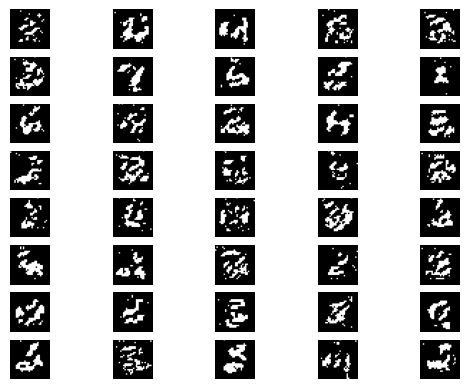

Mean p(x) on test set: 0.000000


In [13]:
with torch.no_grad():
    model_best = torch.load('SBN.model')
    num_x = 8
    num_y = 5
    x = model_best.sample(num_samples=num_x * num_y)
    x = x[0].cpu().detach().numpy()  # Move tensor to CPU before converting to numpy
    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (28, 28))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.show()

    # Calculate p(x) for the test dataset using the trained model
    px_list = []
    for batch in testing_loader:
        x, _ = batch
        x = x.view(x.size(0), -1).to('cuda')  # Flatten and move to correct device
        _, log_px = model_best.evalP(x)
        px_list.append(log_px.cpu())
    px_all = torch.cat(px_list)
    print(f"Mean p(x) on test set: {torch.exp(px_all).mean().item():.6f}")

In [14]:
class NADE(nn.Module):
    """
    NADE with explicit mlp_weights/lr_weights structure and correct masking, including fill().
    """
    def __init__(self, input_size, internal_size=512):
        super().__init__()
        self.input_size = input_size
        self.internal_size = internal_size

        # Degrees for masking
        self.m_input = torch.arange(self.input_size)
        self.m_hidden = torch.from_numpy(
            np.random.randint(0, self.input_size - 1, size=self.internal_size)
        ).sort()[0]

        # Parameters as requested
        self.mlp_weights = nn.Parameter(torch.zeros(self.internal_size, input_size))
        self.mlp_bias = nn.Parameter(torch.zeros(self.internal_size))
        self.lr_weights = nn.Parameter(torch.zeros(input_size, self.internal_size))
        self.lr_bias = nn.Parameter(torch.zeros(input_size))

        nn.init.kaiming_normal_(self.mlp_weights)
        nn.init.kaiming_normal_(self.lr_weights)

        # Masks
        mask1 = (self.m_hidden.unsqueeze(1) >= self.m_input.unsqueeze(0)).float()  # [internal_size, input_size]
        mask2 = (self.m_input.unsqueeze(1) >= self.m_hidden.unsqueeze(0)).float()  # [input_size, internal_size]
        self.register_buffer("mask1", mask1)
        self.register_buffer("mask2", mask2)

        self.activation = nn.Tanh()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        if x.shape[1] != self.input_size:
            raise ValueError(f"Expected input of size {self.input_size}, got {x.shape[1]}")
        # Masked input-to-hidden
        h = self.activation(F.linear(x, self.mlp_weights * self.mask1, self.mlp_bias))  # [batch, internal_size]
        # Masked hidden-to-output
        logits = F.linear(h, self.lr_weights * self.mask2, self.lr_bias)  # [batch, input_size]
        return logits

    def sample(self, num_samples):
        device = self.mlp_weights.device
        samples = torch.zeros(num_samples, self.input_size, device=device)
        for i in range(self.input_size):
            logits = self.forward(samples)
            prob = self.sigmoid(logits[:, i])
            samples[:, i] = torch.bernoulli(prob)
        return samples

    def evalP(self, x):
        if x.ndim == 1:
            x = x.unsqueeze(0)
        logits = self.forward(x)
        log_p_x = torch.sum(
            x * F.logsigmoid(logits) + (1 - x) * F.logsigmoid(-logits),
            dim=1
        )
        p_x = torch.exp(log_p_x)
        return p_x.squeeze(), log_p_x.squeeze()

In [15]:
# Train NADE model using Adam optimizer and binary cross-entropy loss on MNIST data
nade_model = NADE(input_size=D, internal_size=512).to("cuda")
nade_optimizer = torch.optim.Adam(nade_model.parameters(), lr=lr)

# Training loop for NADE
num_epochs_nade = 800

train_models('NADE', num_epochs_nade, nade_model, nade_optimizer, training_loader)

NADE Epoch 000 Loss: 0.5973
NADE Epoch 001 Loss: 0.5070
NADE Epoch 002 Loss: 0.4649
NADE Epoch 003 Loss: 0.4402
NADE Epoch 004 Loss: 0.4219
NADE Epoch 005 Loss: 0.4066
NADE Epoch 006 Loss: 0.3932
NADE Epoch 007 Loss: 0.3809
NADE Epoch 008 Loss: 0.3695
NADE Epoch 009 Loss: 0.3589
NADE Epoch 010 Loss: 0.3490
NADE Epoch 011 Loss: 0.3397
NADE Epoch 012 Loss: 0.3311
NADE Epoch 013 Loss: 0.3231
NADE Epoch 014 Loss: 0.3156
NADE Epoch 015 Loss: 0.3087
NADE Epoch 016 Loss: 0.3022
NADE Epoch 017 Loss: 0.2961
NADE Epoch 018 Loss: 0.2905
NADE Epoch 019 Loss: 0.2852
NADE Epoch 020 Loss: 0.2802
NADE Epoch 021 Loss: 0.2755
NADE Epoch 022 Loss: 0.2711
NADE Epoch 023 Loss: 0.2669
NADE Epoch 024 Loss: 0.2630
NADE Epoch 025 Loss: 0.2592
NADE Epoch 026 Loss: 0.2556
NADE Epoch 027 Loss: 0.2522
NADE Epoch 028 Loss: 0.2489
NADE Epoch 029 Loss: 0.2458
NADE Epoch 030 Loss: 0.2428
NADE Epoch 031 Loss: 0.2399
NADE Epoch 032 Loss: 0.2371
NADE Epoch 033 Loss: 0.2344
NADE Epoch 034 Loss: 0.2319
NADE Epoch 035 Loss:

<ipython-input-16-0461d388d225>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_best = torch.load('NADE.model')


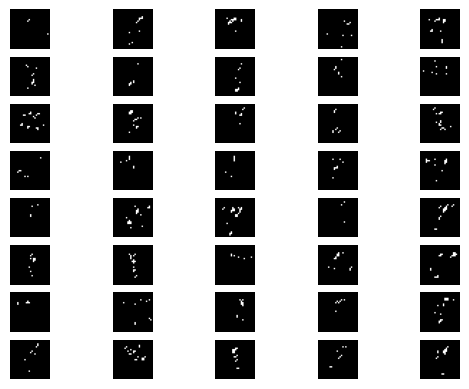

Mean p(x) on test set: 0.000000


In [16]:
with torch.no_grad():
    model_best = torch.load('NADE.model')
    num_x = 8
    num_y = 5
    x = model_best.sample(num_samples=num_x * num_y)
    x = x.cpu().detach().numpy()  # Move tensor to CPU before converting to numpy
    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (28, 28))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.show()

    # Calculate p(x) for the test dataset using the trained model
    px_list = []
    for batch in testing_loader:
        x, _ = batch
        x = x.view(x.size(0), -1).to('cuda')  # Flatten and move to correct device
        _, log_px = model_best.evalP(x)
        px_list.append(log_px.cpu())
    px_all = torch.cat(px_list)
    print(f"Mean p(x) on test set: {torch.exp(px_all).mean().item():.6f}")

In [17]:
class NADERnn(nn.Module):
    def __init__(self, input_size, internal_size=64):
        super().__init__()
        self.input_size = input_size
        self.internal_size = internal_size
        self.rnn = nn.GRU(1, internal_size, num_layers=1, batch_first=True)

        # Output weights: one logit per pixel
        self.lr_weights = nn.Parameter(torch.empty(input_size, internal_size))
        self.lr_bias = nn.Parameter(torch.zeros(input_size))

        nn.init.kaiming_normal_(self.lr_weights)
        self.activation = nn.Tanh()

    def forward(self, x):
        """
        Teacher-forced forward pass.
        Autoregressively predicts probabilities for each dimension.
        """
        batch_size = x.size(0)
        h = torch.zeros(1, batch_size, self.internal_size, device=x.device)

        probs = []
        for i in range(self.input_size):
            if i == 0:
                # First pixel: no input yet, just use h0
                h_t = self.activation(h[0])  # [batch, hidden]
            else:
                # Feed previous true pixel into GRU
                out, h = self.rnn(x[:, i-1:i].unsqueeze(-1), h)  # [batch, 1, hidden]
                h_t = self.activation(out[:, -1, :])  # [batch, hidden]

            # Predict prob for pixel i
            logit = h_t @ self.lr_weights[i].unsqueeze(1) + self.lr_bias[i]
            prob = torch.sigmoid(logit)
            probs.append(prob)

        return torch.cat(probs, dim=1)  # [batch, input_size]

    def sample(self, num_samples):
        """
        Sequential ancestral sampling.
        """
        device = self.lr_weights.device
        samples = torch.zeros(num_samples, self.input_size, device=device)
        probs = torch.zeros_like(samples)

        h = torch.zeros(1, num_samples, self.internal_size, device=device)

        for i in range(self.input_size):
            if i == 0:
                h_t = self.activation(h[0])
            else:
                out, h = self.rnn(samples[:, i-1:i].unsqueeze(-1), h)
                h_t = self.activation(out[:, -1, :])

            logit = h_t @ self.lr_weights[i].unsqueeze(1) + self.lr_bias[i]
            prob = torch.sigmoid(logit).squeeze(-1)
            probs[:, i] = prob
            samples[:, i] = torch.bernoulli(prob)

        return samples, probs

    def evalP(self, x):
        """
        Compute p(x) and log p(x).
        """
        if x.ndim == 1:
            x = x.unsqueeze(0)

        prob_vec = self.forward(x)
        p_x = torch.prod(prob_vec * x + (1 - prob_vec) * (1 - x), dim=1)
        log_p_x = torch.sum(
            x * torch.log(prob_vec + 1e-8) +
            (1 - x) * torch.log(1 - prob_vec + 1e-8),
            dim=1
        )
        return p_x.squeeze(), log_p_x.squeeze()


In [18]:
# Train NADERnn model using Adam optimizer and binary cross-entropy loss on MNIST data
nadernn_model = NADERnn(input_size=D, internal_size=16).to("cuda")
nadernn_optimizer = torch.optim.Adam(nadernn_model.parameters(), lr=lr)

# Training loop for NADERnn
num_epochs_nadern = 100

train_models('NADERnn', num_epochs_nadern, nadernn_model, nadernn_optimizer, training_loader)

NADERnn Epoch 000 Loss: 0.9014
NADERnn Epoch 001 Loss: 0.8984
NADERnn Epoch 002 Loss: 0.8946
NADERnn Epoch 003 Loss: 0.8894
NADERnn Epoch 004 Loss: 0.8820
NADERnn Epoch 005 Loss: 0.8709
NADERnn Epoch 006 Loss: 0.8559
NADERnn Epoch 007 Loss: 0.8412
NADERnn Epoch 008 Loss: 0.8292
NADERnn Epoch 009 Loss: 0.8193
NADERnn Epoch 010 Loss: 0.8105
NADERnn Epoch 011 Loss: 0.8028
NADERnn Epoch 012 Loss: 0.7958
NADERnn Epoch 013 Loss: 0.7894
NADERnn Epoch 014 Loss: 0.7836
NADERnn Epoch 015 Loss: 0.7782
NADERnn Epoch 016 Loss: 0.7733
NADERnn Epoch 017 Loss: 0.7688
NADERnn Epoch 018 Loss: 0.7646
NADERnn Epoch 019 Loss: 0.7607
NADERnn Epoch 020 Loss: 0.7570
NADERnn Epoch 021 Loss: 0.7536
NADERnn Epoch 022 Loss: 0.7505
NADERnn Epoch 023 Loss: 0.7475
NADERnn Epoch 024 Loss: 0.7448
NADERnn Epoch 025 Loss: 0.7422
NADERnn Epoch 026 Loss: 0.7398
NADERnn Epoch 027 Loss: 0.7375
NADERnn Epoch 028 Loss: 0.7354
NADERnn Epoch 029 Loss: 0.7334
NADERnn Epoch 030 Loss: 0.7316
NADERnn Epoch 031 Loss: 0.7298
NADERnn 

<ipython-input-19-387dd220cee8>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_best = torch.load('NADERnn.model')


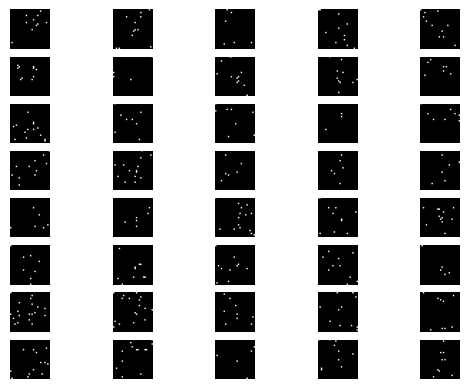

Mean p(x) on test set: 0.000000


In [19]:
with torch.no_grad():
    model_best = torch.load('NADERnn.model')
    num_x = 8
    num_y = 5
    x = model_best.sample(num_samples=num_x * num_y)
    x = x[0].cpu().detach().numpy()  # Move tensor to CPU before converting to numpy
    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (28, 28))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.show()

    # Calculate p(x) for the test dataset using the trained model
    px_list = []
    for batch in testing_loader:
        x, _ = batch
        x = x.view(x.size(0), -1).to('cuda')  # Flatten and move to correct device
        _, log_px = model_best.evalP(x)
        px_list.append(log_px.cpu())
    px_all = torch.cat(px_list)
    print(f"Mean p(x) on test set: {torch.exp(px_all).mean().item():.6f}")

In [20]:
class CausalConv1d(nn.Module):

    """
    A causal 1D convolution.
    Implementation from Tomczak.
    """
    def __init__(self, in_channels, out_channels, kernel_size, dilation,exclude_current=False, **kwargs):
        super(CausalConv1d, self).__init__()
        # attributes:
        self.kernel_size = kernel_size
        self.dilation = dilation
        self.exclude_current = exclude_current
        self.padding = (kernel_size - 1) * dilation + (1 if exclude_current else 0) * dilation
        # module:
        self.conv1d = torch.nn.Conv1d(in_channels, out_channels,
                                      kernel_size, stride=1,
                                      padding=0,
                                      dilation=dilation,
                                      **kwargs)

    def forward(self, x):
        # Here is the trick!
        x = torch.nn.functional.pad(x, (self.padding, 0))
        conv1d_out = self.conv1d(x)
        if self.exclude_current:
            return conv1d_out[:, :, : -1]
        else:
            return conv1d_out

In [21]:
class CausalConvARM(nn.Module):
    def __init__(self, input_size=2):
        super(CausalConvARM, self).__init__()
        self.kernel_size = 11
        self.n_channels = 32
        self.sigmoid = nn.Sigmoid()
        self.net = nn.Sequential(
            CausalConv1d(in_channels=1, out_channels=self.n_channels,dilation=1, kernel_size=self.kernel_size, exclude_current=True, bias=True),
            nn.LeakyReLU(),
            CausalConv1d(in_channels=self.n_channels, out_channels=self.n_channels, dilation=2, kernel_size=self.kernel_size, exclude_current=False, bias=True),
            nn.LeakyReLU(),
            CausalConv1d(in_channels=self.n_channels, out_channels=self.n_channels, dilation=2, kernel_size=self.kernel_size, exclude_current=False, bias=True),
            nn.LeakyReLU(),
            CausalConv1d(in_channels=self.n_channels, out_channels=self.n_channels, dilation=1, kernel_size=self.kernel_size, exclude_current=False, bias=True)
        )
        # Define the logistic regression weights and bias
        self.lr_weights = torch.nn.Parameter(torch.zeros(input_size,self.n_channels))
        self.lr_bias = torch.nn.Parameter(torch.zeros(input_size))
        self.input_size = input_size

    def forward(self, x):
        h = self.net(x.unsqueeze(1))
        h = h.permute(0, 2, 1)
        sp= torch.sum(h*self.lr_weights,dim=2)+self.lr_bias
        return sp.squeeze(-1)

    def sample(self, num_samples):
        device = next(self.parameters()).device
        samples = torch.zeros(num_samples, self.input_size).to(device)
        probs = torch.zeros(num_samples, self.input_size).to(device)
        for i in range(self.input_size):
            logits = self.forward(samples)
            prob = self.sigmoid(logits)
            probs[:, i] = prob[:,i]
            # Sample from the Bernoulli distribution
            samples[:, i] = torch.bernoulli(probs[:, i])
        return samples, probs
    # Calculate p(x) and log p(x) for a given input x
    def evalP(self, x):
        """
        Evaluate the probability p(x) for a given input x.
        x: torch.Tensor of shape [input_size] or [1, input_size]
        Returns: probability p(x) and log-probability log p(x)
        """
        if x.ndim == 1:
            x = x.unsqueeze(0)
        logits = self.forward(x)
        prob_vec = torch.sigmoid(logits)
        p_x = torch.prod(prob_vec * x + (1 - prob_vec) * (1 - x), dim=1)
        log_p_x = torch.sum(x * torch.log(prob_vec + 1e-8) + (1 - x) * torch.log(1 - prob_vec + 1e-8), dim=1)
        return p_x.squeeze(), log_p_x.squeeze()

In [22]:
# Train CausalConvARM model using Adam optimizer and binary cross-entropy loss on MNIST data
causalconvarm_model = CausalConvARM(input_size=D).to("cuda")
causalconvarm_optimizer = torch.optim.Adam(causalconvarm_model.parameters(), lr=lr)

# Training loop for CausalConvARM
num_epochs_causalconvarm = 800
train_models("CausalConvARM", num_epochs_causalconvarm, causalconvarm_model, causalconvarm_optimizer, training_loader)


CausalConvARM Epoch 000 Loss: 0.5780
CausalConvARM Epoch 001 Loss: 0.3027
CausalConvARM Epoch 002 Loss: 0.2885
CausalConvARM Epoch 003 Loss: 0.2802
CausalConvARM Epoch 004 Loss: 0.2706
CausalConvARM Epoch 005 Loss: 0.2605
CausalConvARM Epoch 006 Loss: 0.2494
CausalConvARM Epoch 007 Loss: 0.2265
CausalConvARM Epoch 008 Loss: 0.2128
CausalConvARM Epoch 009 Loss: 0.1995
CausalConvARM Epoch 010 Loss: 0.1835
CausalConvARM Epoch 011 Loss: 0.1749
CausalConvARM Epoch 012 Loss: 0.1680
CausalConvARM Epoch 013 Loss: 0.1620
CausalConvARM Epoch 014 Loss: 0.1577
CausalConvARM Epoch 015 Loss: 0.1539
CausalConvARM Epoch 016 Loss: 0.1503
CausalConvARM Epoch 017 Loss: 0.1472
CausalConvARM Epoch 018 Loss: 0.1443
CausalConvARM Epoch 019 Loss: 0.1416
CausalConvARM Epoch 020 Loss: 0.1390
CausalConvARM Epoch 021 Loss: 0.1368
CausalConvARM Epoch 022 Loss: 0.1350
CausalConvARM Epoch 023 Loss: 0.1335
CausalConvARM Epoch 024 Loss: 0.1322
CausalConvARM Epoch 025 Loss: 0.1311
CausalConvARM Epoch 026 Loss: 0.1302
C

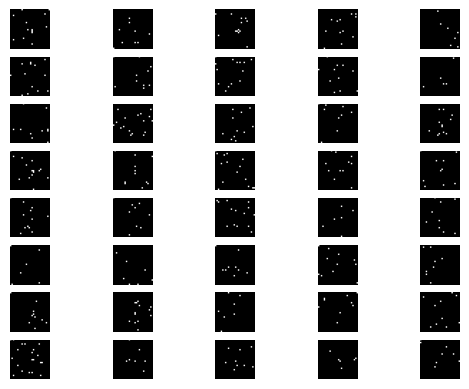

Mean p(x) on test set: 0.000000


In [23]:
with torch.no_grad():
    num_x = 8
    num_y = 5
    x = model_best.sample(num_samples=num_x * num_y)
    x = x[0].cpu().detach().numpy()  # Move tensor to CPU before converting to numpy
    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (28, 28))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.show()

    # Calculate p(x) for the test dataset using the trained model
    px_list = []
    for batch in testing_loader:
        x, _ = batch
        x = x.view(x.size(0), -1).to('cuda')  # Flatten and move to correct device
        _, log_px = model_best.evalP(x)
        px_list.append(log_px.cpu())
    px_all = torch.cat(px_list)
    print(f"Mean p(x) on test set: {torch.exp(px_all).mean().item():.6f}")

Ninguna de las redes funcionó de acuerdo a lo esperado. Es posible que fueran sobre-entrenadas o que requirieran mucho más entrenamiento, pero $p(x)$ en promedio es cero para todas, no he encontrado ningún error después de varios días buscando, por lo que si pudiera decirme qué falta, se lo agradecería. El modelo de NADE lo reescribí pues tardaba demasiado el entrenamiento, pero conservé la estructura original.

# Problema 2

Consideramos una factorización bivarioada para el modelo NADE. Para hacerlo, proponemos que la salida sea la probabilidad de cada uno de los siguientes casos:
\begin{align}
(X_1,X_2) &= (0,0), & (X_1,X_2) &= (0,1)\\
(X_1,X_2) &= (1,0), & (X_1,X_2) &= (1,1)
\end{align}
La función de pérdida sigue siendo la entropía cruzada.

In [ ]:
class BivariateNADE(nn.Module):
    """
    Bivariate NADE with explicit mlp_weights/lr_weights structure and correct masking.
    Output: 4 logits per pixel pair.
    """
    def __init__(self, input_size, internal_size=512):
        super().__init__()

        # Ensure even input size (pairs of pixels)
        self.input_size = input_size if input_size % 2 == 0 else input_size + 1
        self.internal_size = internal_size
        self.n_pairs = self.input_size // 2

        # Degrees
        self.m_input = torch.arange(self.input_size)  # 0..D-1
        self.m_hidden = torch.from_numpy(
            np.random.randint(0, self.input_size - 1, size=self.internal_size)
        ).sort()[0]

        # Parameters (same structure as NADE)
        self.mlp_weights = nn.Parameter(torch.zeros(self.internal_size, self.input_size))
        self.mlp_bias = nn.Parameter(torch.zeros(self.internal_size))
        self.lr_weights = nn.Parameter(torch.zeros(4 * self.n_pairs, self.internal_size))
        self.lr_bias = nn.Parameter(torch.zeros(4 * self.n_pairs))

        nn.init.kaiming_normal_(self.mlp_weights)
        nn.init.kaiming_normal_(self.lr_weights)

        # Mask 1: input -> hidden
        mask1 = (self.m_hidden.unsqueeze(1) >= self.m_input.unsqueeze(0)).float()  # [internal_size, input_size]

        # Mask 2: hidden -> output
        m_output_pairs = torch.arange(self.n_pairs) * 2 + 1  # degree for each pair
        mask2 = (m_output_pairs.unsqueeze(1) >= self.m_hidden.unsqueeze(0)).float()  # [n_pairs, internal_size]
        mask2 = mask2.repeat_interleave(4, dim=0)  # [4*n_pairs, internal_size]

        self.register_buffer("mask1", mask1)
        self.register_buffer("mask2", mask2)

        self.activation = nn.Tanh()

    def forward(self, x):
        """
        Forward pass: returns logits for each pair.
        x: [batch, input_size]
        output: [batch, n_pairs, 4]
        """
        if x.shape[1] != self.input_size:
            pad = self.input_size - x.shape[1]
            x = F.pad(x, (0, pad), "constant", 0)

        h = self.activation(F.linear(x, self.mlp_weights * self.mask1, self.mlp_bias))  # [batch, internal_size]
        logits = F.linear(h, self.lr_weights * self.mask2, self.lr_bias)  # [batch, 4*n_pairs]
        logits = logits.view(-1, self.n_pairs, 4)
        return logits

    def sample(self, num_samples):
        """
        Sequentially sample pairs according to autoregressive ordering.
        """
        device = self.mlp_weights.device
        samples = torch.zeros(num_samples, self.input_size, device=device)

        for i in range(self.n_pairs):
            logits = self.forward(samples)  # [num_samples, n_pairs, 4]
            logits_pair = logits[:, i, :]   # [num_samples, 4]
            probs = F.softmax(logits_pair, dim=-1)
            idx = torch.multinomial(probs, 1).squeeze(1)  # [num_samples]
            # Decode idx to two bits
            samples[:, 2*i]   = (idx >> 1) & 1
            samples[:, 2*i+1] = idx & 1

        return samples[:, :self.input_size]

    def evalP(self, x):
        if x.ndim == 1:
            x = x.unsqueeze(0)
        if x.shape[1] != self.input_size:
            pad = self.input_size - x.shape[1]
            x = F.pad(x, (0, pad), "constant", 0)
        logits = self.forward(x)  # [batch, n_pairs, 4]
        probs = F.softmax(logits, dim=-1)  # [batch, n_pairs, 4]

        # Compute indices for all pairs in batch
        pair_bits = x.view(x.shape[0], self.n_pairs, 2).long()
        idx = (pair_bits[:,:,0] << 1) + pair_bits[:,:,1]  # [batch, n_pairs]

        # Gather probabilities for each pair
        px = probs.gather(2, idx.unsqueeze(-1)).squeeze(-1)  # [batch, n_pairs]
        log_px = torch.log(px + 1e-8)  # [batch, n_pairs]

        # Product and sum over pairs
        p_x = torch.prod(px, dim=1)
        log_p_x = torch.sum(log_px, dim=1)
        return p_x.squeeze(), log_p_x.squeeze()

In [25]:
# Train bivariateNADE model using Adam optimizer and cross-entropy loss on MNIST data
bivnade_model = BivariateNADE(input_size=D, internal_size=512).to("cuda")
bivnade_optimizer = torch.optim.Adam(bivnade_model.parameters(), lr=lr)

num_epochs_bivnade = 500

bv_min_loss = float('inf')
for epoch in range(num_epochs_bivnade):
    bivnade_model.train()
    for batch_idx, (x, y) in enumerate(training_loader):
        x = x.view(x.size(0), -1).to("cuda")  # Flatten MNIST images
        # Pad if needed
        if x.shape[1] % 2 != 0:
            x = F.pad(x, (0, 1), 'constant', 0)
        logits = bivnade_model(x)  # [batch, n_pairs, 4]
        # Prepare targets: for each pair, get index 0-3
        targets = []
        for i in range(bivnade_model.n_pairs):
            pair = x[:, 2*i:2*i+2]
            idx = (pair[:, 0].long() << 1) + pair[:, 1].long()
            targets.append(idx)
        targets = torch.stack(targets, dim=1)  # [batch, n_pairs]
        # Reshape logits and targets for cross-entropy
        logits_flat = logits.view(-1, 4)
        targets_flat = targets.view(-1)
        bv_loss = F.cross_entropy(logits_flat, targets_flat)
        bivnade_optimizer.zero_grad()
        bv_loss.backward()
        bivnade_optimizer.step()
        if bv_loss.item() < bv_min_loss:
            bv_min_loss = bv_loss.item()
            torch.save(bivnade_model, 'bivnade.model')
    print(f"Bivariate NADE Epoch {epoch:03d} Loss: {bv_loss.item():.4f}")

Bivariate NADE Epoch 000 Loss: 1.0040
Bivariate NADE Epoch 001 Loss: 0.6629
Bivariate NADE Epoch 002 Loss: 0.5226
Bivariate NADE Epoch 003 Loss: 0.4499
Bivariate NADE Epoch 004 Loss: 0.4010
Bivariate NADE Epoch 005 Loss: 0.3628
Bivariate NADE Epoch 006 Loss: 0.3305
Bivariate NADE Epoch 007 Loss: 0.3021
Bivariate NADE Epoch 008 Loss: 0.2768
Bivariate NADE Epoch 009 Loss: 0.2542
Bivariate NADE Epoch 010 Loss: 0.2340
Bivariate NADE Epoch 011 Loss: 0.2161
Bivariate NADE Epoch 012 Loss: 0.2003
Bivariate NADE Epoch 013 Loss: 0.1863
Bivariate NADE Epoch 014 Loss: 0.1741
Bivariate NADE Epoch 015 Loss: 0.1633
Bivariate NADE Epoch 016 Loss: 0.1538
Bivariate NADE Epoch 017 Loss: 0.1455
Bivariate NADE Epoch 018 Loss: 0.1381
Bivariate NADE Epoch 019 Loss: 0.1316
Bivariate NADE Epoch 020 Loss: 0.1258
Bivariate NADE Epoch 021 Loss: 0.1207
Bivariate NADE Epoch 022 Loss: 0.1160
Bivariate NADE Epoch 023 Loss: 0.1119
Bivariate NADE Epoch 024 Loss: 0.1081
Bivariate NADE Epoch 025 Loss: 0.1047
Bivariate NA

<ipython-input-26-55413bc5a8d4>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_best = torch.load('bivnade.model')


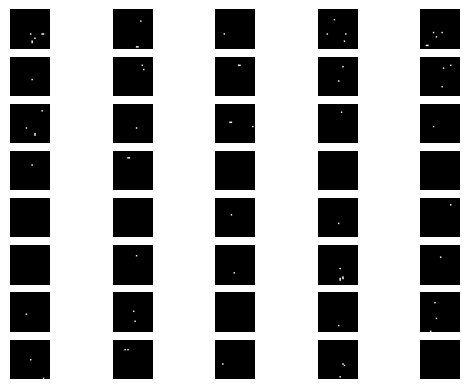

Mean p(x) on test set: 0.005787


In [26]:
with torch.no_grad():
    model_best = torch.load('bivnade.model')
    num_x = 8
    num_y = 5
    x = model_best.sample(num_samples=num_x * num_y)
    x = x.cpu().detach().numpy()
    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (28, 28))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.show()

    # Calculate p(x) for the test dataset using the trained model
    px_list = []
    for batch in testing_loader:
        x, _ = batch
        x = x.view(x.size(0), -1).to('cuda')  # Flatten and move to correct device
        px, _ = model_best.evalP(x)
        px_list.append(px.cpu())
    px_all = torch.cat(px_list)
    print(f"Mean p(x) on test set: {px_all.mean().item():.6f}")

En este caso, $p(x)$ no es cero en promedio, pero si es bastante baja. No hay una clara diferencia entre los dos modelos, si acaso el NADE original es cualitativamente mejor.

# Problema 3

Añadimos la función fill a la clase de NADE, donde utilizamos una máscara para elegir si completamos un dígito o utilizamos el provisto. Por la implementación, es posible considerar imágenes con otra estructura faltante.

In [27]:
class NADE(nn.Module):
    """
    NADE with explicit mlp_weights/lr_weights structure and correct masking, including fill().
    """
    def __init__(self, input_size, internal_size=512):
        super().__init__()
        self.input_size = input_size
        self.internal_size = internal_size

        # Degrees for masking
        self.m_input = torch.arange(self.input_size)
        self.m_hidden = torch.from_numpy(
            np.random.randint(0, self.input_size - 1, size=self.internal_size)
        ).sort()[0]

        # Parameters as requested
        self.mlp_weights = nn.Parameter(torch.zeros(self.internal_size, input_size))
        self.mlp_bias = nn.Parameter(torch.zeros(self.internal_size))
        self.lr_weights = nn.Parameter(torch.zeros(input_size, self.internal_size))
        self.lr_bias = nn.Parameter(torch.zeros(input_size))

        nn.init.kaiming_normal_(self.mlp_weights)
        nn.init.kaiming_normal_(self.lr_weights)

        # Masks
        mask1 = (self.m_hidden.unsqueeze(1) >= self.m_input.unsqueeze(0)).float()  # [internal_size, input_size]
        mask2 = (self.m_input.unsqueeze(1) >= self.m_hidden.unsqueeze(0)).float()  # [input_size, internal_size]
        self.register_buffer("mask1", mask1)
        self.register_buffer("mask2", mask2)

        self.activation = nn.Tanh()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        if x.shape[1] != self.input_size:
            raise ValueError(f"Expected input of size {self.input_size}, got {x.shape[1]}")
        # Masked input-to-hidden
        h = self.activation(F.linear(x, self.mlp_weights * self.mask1, self.mlp_bias))  # [batch, internal_size]
        # Masked hidden-to-output
        logits = F.linear(h, self.lr_weights * self.mask2, self.lr_bias)  # [batch, input_size]
        return logits

    def sample(self, num_samples):
        device = self.mlp_weights.device
        samples = torch.zeros(num_samples, self.input_size, device=device)
        for i in range(self.input_size):
            logits = self.forward(samples)
            prob = self.sigmoid(logits[:, i])
            samples[:, i] = torch.bernoulli(prob)
        return samples

    def evalP(self, x):
        if x.ndim == 1:
            x = x.unsqueeze(0)
        logits = self.forward(x)
        log_p_x = torch.sum(
            x * F.logsigmoid(logits) + (1 - x) * F.logsigmoid(-logits),
            dim=1
        )
        p_x = torch.exp(log_p_x)
        return p_x.squeeze(), log_p_x.squeeze()

    def fill(self, x_partial, mask=None):
        """
        Fill missing pixels in an image using the NADE model.
        Args:
            x_partial: [input_size] or [batch, input_size], known pixels set, unknowns = 0 or any value.
            mask: same shape, 1=known, 0=unknown. If None, treat zeros as unknowns.
        Returns:
            x_filled: completed image
        """
        if x_partial.ndim == 1:
            x_partial = x_partial.unsqueeze(0)
        batch_size, input_size = x_partial.shape
        x_filled = x_partial.clone()
        if mask is None:
            mask = (x_partial != 0).float()
        for i in range(input_size):
            missing = (mask[:, i] == 0)
            if missing.any():
                logits = self.forward(x_filled)
                prob = self.sigmoid(logits)[:, i]
                x_filled[missing, i] = torch.bernoulli(prob[missing])
                mask[missing, i] = 1
        return x_filled.squeeze(0) if batch_size == 1 else x_filled

Cargamos el mejor modelo en vez de entrenar nuevamente.

In [28]:
# Train NADE model using Adam optimizer and binary cross-entropy loss on MNIST data
nade_model = NADE(input_size=D, internal_size=512).to("cuda")

# Load trained NADE model weights
nade_model.load_state_dict(torch.load('NADE.model').state_dict())
nade_model.eval()

<ipython-input-28-2c80e9794ed7>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  nade_model.load_state_dict(torch.load('NADE.model').state_dict())


NADE(
  (activation): Tanh()
  (sigmoid): Sigmoid()
)

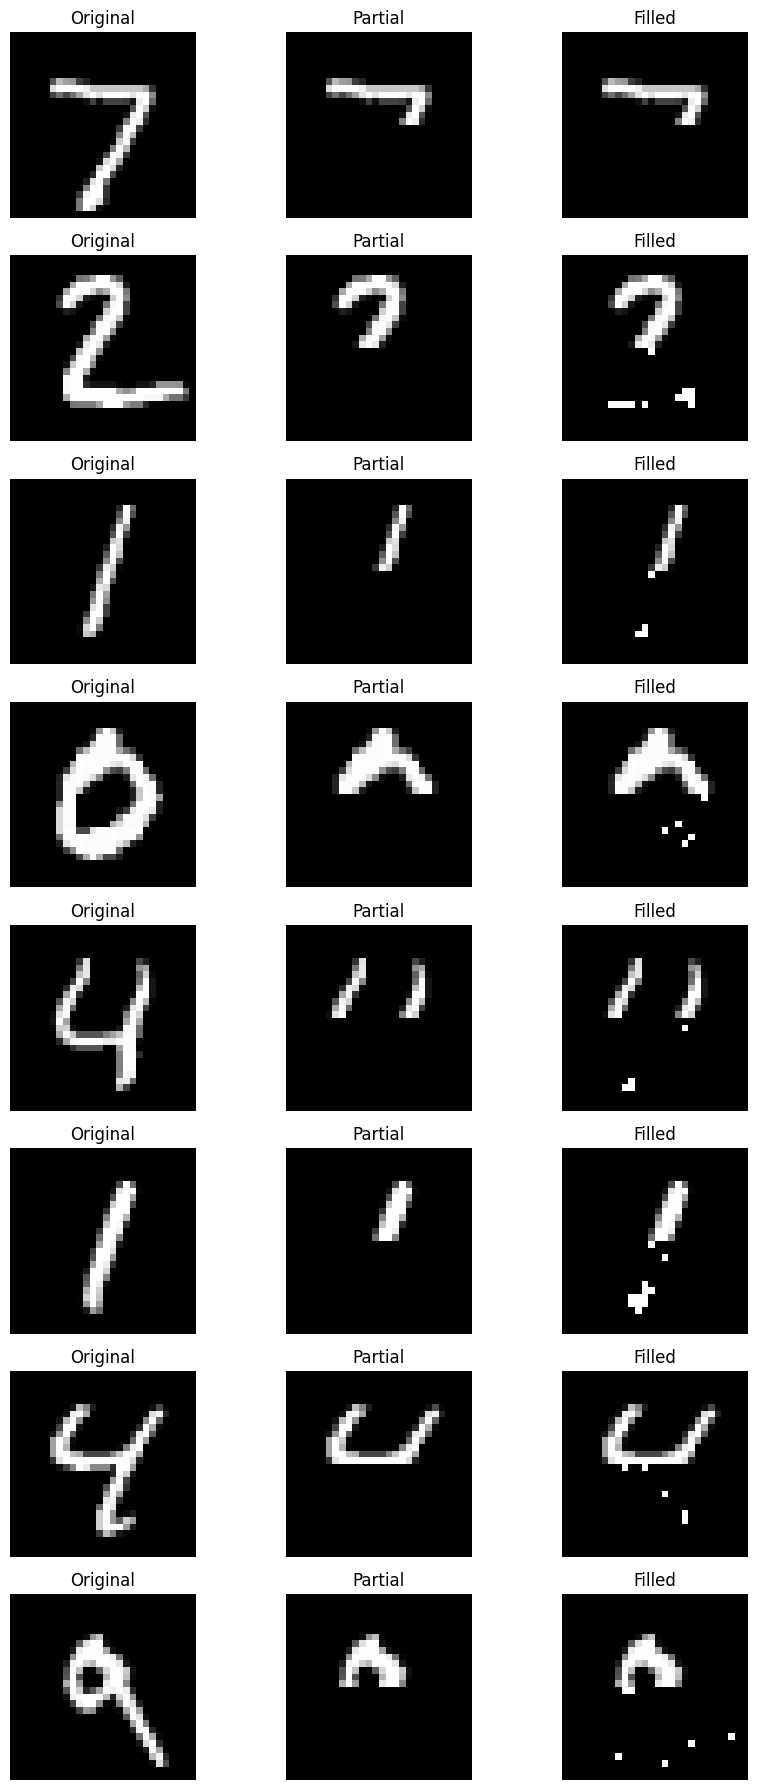

In [29]:
with torch.no_grad():
    # Get a batch from the testing dataset
    for batch in testing_loader:
        x, y = batch
        x = x.view(x.size(0), 28, 28)  # Reshape to [batch, 28, 28]
        # Only use the first 8 images for visualization
        x = x[:8]
        # Create partial images: keep first 14 rows, zero out the rest
        x_partial = x.clone()
        x_partial[:, 14:, :] = 0

        # Define a mask where known pixels are marked as 1 and unknown as 0
        mask = torch.ones_like(x)
        mask[:, 14:, :] = 0

        # Flatten for NADE input
        x_partial_flat = x_partial.view(x_partial.size(0), -1).to('cuda')
        mask_flat = mask.view(mask.size(0), -1).to('cuda')
        # Fill missing pixels
        x_filled_flat = nade_model.fill(x_partial_flat, mask = mask_flat)
        x_filled = x_filled_flat.cpu().numpy().reshape(-1, 28, 28)
        # Visualize original, partial, and filled images
        fig, axes = plt.subplots(8, 3, figsize=(9, 18))
        for i in range(8):
            axes[i, 0].imshow(x[i].cpu().numpy(), cmap='gray')
            axes[i, 0].set_title('Original')
            axes[i, 0].axis('off')
            axes[i, 1].imshow(x_partial[i].cpu().numpy(), cmap='gray')
            axes[i, 1].set_title('Partial')
            axes[i, 1].axis('off')
            axes[i, 2].imshow(x_filled[i], cmap='gray')
            axes[i, 2].set_title('Filled')
            axes[i, 2].axis('off')
        plt.tight_layout()
        plt.show()
        break  # Only process one batch

Para el problema de completar, podemos identificar algunos números, pero en general seguimos teniendo un mal desempeño.

# Problema 4
Añadimos la posibilidad de permutar los datos, tanto al entrenamiento, como a la función de fill previamente creada. Proponemos las siguientes permutaciones:

- Recorrer verticalmente desde el inicio.
- Recorrer horizontalmente desde el último pixel
- Recorrer horizontalmente desde la fila central, hacia abajo y hacia arriba alternadamente
- Recorrer verticalmente desde la columna central, hacia la derecha e izquierda alternadamente
- Una espiral desde los extremos hacia el centro


In [30]:
class NADE(nn.Module):
    """
    NADE with explicit mlp_weights/lr_weights structure and correct masking, including fill().
    """
    def __init__(self, input_size, internal_size=512, permutation=None):
        super().__init__()
        self.input_size = input_size
        self.internal_size = internal_size

        # Degrees for masking
        self.m_input = torch.arange(self.input_size)
        self.m_hidden = torch.from_numpy(
            np.random.randint(0, self.input_size - 1, size=self.internal_size)
        ).sort()[0]

        # Parameters as requested
        self.mlp_weights = nn.Parameter(torch.zeros(self.internal_size, input_size))
        self.mlp_bias = nn.Parameter(torch.zeros(self.internal_size))
        self.lr_weights = nn.Parameter(torch.zeros(input_size, self.internal_size))
        self.lr_bias = nn.Parameter(torch.zeros(input_size))

        nn.init.kaiming_normal_(self.mlp_weights)
        nn.init.kaiming_normal_(self.lr_weights)

        # Masks
        mask1 = (self.m_hidden.unsqueeze(1) >= self.m_input.unsqueeze(0)).float()  # [internal_size, input_size]
        mask2 = (self.m_input.unsqueeze(1) >= self.m_hidden.unsqueeze(0)).float()  # [input_size, internal_size]
        self.register_buffer("mask1", mask1)
        self.register_buffer("mask2", mask2)

        self.activation = nn.Tanh()
        self.sigmoid = nn.Sigmoid()

        # Permutation: if None, identity
        if permutation is None:
            self.register_buffer("permutation", torch.arange(input_size))
        else:
            self.register_buffer("permutation", torch.tensor(permutation, dtype=torch.long))

    def forward(self, x):
        if x.shape[1] != self.input_size:
            raise ValueError(f"Expected input of size {self.input_size}, got {x.shape[1]}")

        x_perm = x[:, self.permutation] if x.ndim == 2 else x[self.permutation]

        # Masked input-to-hidden
        h = self.activation(F.linear(x_perm, self.mlp_weights * self.mask1, self.mlp_bias))  # [batch, internal_size]

        # Masked hidden-to-output
        logits = F.linear(h, self.lr_weights * self.mask2, self.lr_bias)  # [batch, input_size]
        inv_perm = torch.argsort(self.permutation)
        logits = logits[:, inv_perm] if logits.ndim == 2 else logits[inv_perm]
        return logits


    def sample(self, num_samples):
        device = self.mlp_weights.device
        samples = torch.zeros(num_samples, self.input_size, device=device)
        for idx in self.permutation:
            logits = self.forward(samples)
            prob = self.sigmoid(logits[:, idx])
            samples[:, idx] = torch.bernoulli(prob)
        return samples


    def evalP(self, x):
        if x.ndim == 1:
            x = x.unsqueeze(0)
        logits = self.forward(x)
        log_p_x = torch.sum(
            x * F.logsigmoid(logits) + (1 - x) * F.logsigmoid(-logits),
            dim=1
        )
        p_x = torch.exp(log_p_x)
        return p_x.squeeze(), log_p_x.squeeze()

    def fill(self, x_partial, mask=None):
        if x_partial.ndim == 1:
            x_partial = x_partial.unsqueeze(0)
        batch_size, input_size = x_partial.shape
        x_filled = x_partial.clone()
        if mask is None:
            mask = (x_partial != 0).float()
        for idx in self.permutation:
            missing = (mask[:, idx] == 0)
            if missing.any():
                logits = self.forward(x_filled)
                prob = self.sigmoid(logits)[:, idx]
                x_filled[missing, idx] = torch.bernoulli(prob[missing])
                mask[missing, idx] = 1
        return x_filled.squeeze(0) if batch_size == 1 else x_filled

Aquí utilicé 200 épocas por cada permutación, y al final comparamos.

In [31]:
# p1: permutation for vertical (column-major) order for MNIST 28x28 images
p1 = [i + 28*j for i in range(28) for j in range(28)]
p1_nade_model = NADE(input_size=D, internal_size=512, permutation=p1).to("cuda")

p1_nade_optimizer = torch.optim.Adam(p1_nade_model.parameters(), lr=lr)

# Training loop for permutated NADEs
num_epochs_nade_p = 200

train_models('P1_NADE', num_epochs_nade_p, p1_nade_model, p1_nade_optimizer, training_loader)


P1_NADE Epoch 000 Loss: 0.6019
P1_NADE Epoch 001 Loss: 0.5183
P1_NADE Epoch 002 Loss: 0.4806
P1_NADE Epoch 003 Loss: 0.4582
P1_NADE Epoch 004 Loss: 0.4406
P1_NADE Epoch 005 Loss: 0.4252
P1_NADE Epoch 006 Loss: 0.4109
P1_NADE Epoch 007 Loss: 0.3974
P1_NADE Epoch 008 Loss: 0.3845
P1_NADE Epoch 009 Loss: 0.3723
P1_NADE Epoch 010 Loss: 0.3607
P1_NADE Epoch 011 Loss: 0.3498
P1_NADE Epoch 012 Loss: 0.3395
P1_NADE Epoch 013 Loss: 0.3300
P1_NADE Epoch 014 Loss: 0.3211
P1_NADE Epoch 015 Loss: 0.3128
P1_NADE Epoch 016 Loss: 0.3052
P1_NADE Epoch 017 Loss: 0.2981
P1_NADE Epoch 018 Loss: 0.2915
P1_NADE Epoch 019 Loss: 0.2854
P1_NADE Epoch 020 Loss: 0.2798
P1_NADE Epoch 021 Loss: 0.2745
P1_NADE Epoch 022 Loss: 0.2697
P1_NADE Epoch 023 Loss: 0.2651
P1_NADE Epoch 024 Loss: 0.2608
P1_NADE Epoch 025 Loss: 0.2568
P1_NADE Epoch 026 Loss: 0.2530
P1_NADE Epoch 027 Loss: 0.2494
P1_NADE Epoch 028 Loss: 0.2460
P1_NADE Epoch 029 Loss: 0.2428
P1_NADE Epoch 030 Loss: 0.2397
P1_NADE Epoch 031 Loss: 0.2368
P1_NADE 

In [32]:
# p2: reverse permutation (from end to beginning)
p2 = list(reversed(range(D)))
p2_nade_model = NADE(input_size=D, internal_size=512, permutation=p2).to("cuda")

p2_nade_optimizer = torch.optim.Adam(p2_nade_model.parameters(), lr=lr)

train_models('P2_NADE', num_epochs_nade_p, p2_nade_model, p2_nade_optimizer, training_loader)


P2_NADE Epoch 000 Loss: 0.5802
P2_NADE Epoch 001 Loss: 0.4830
P2_NADE Epoch 002 Loss: 0.4383
P2_NADE Epoch 003 Loss: 0.4130
P2_NADE Epoch 004 Loss: 0.3951
P2_NADE Epoch 005 Loss: 0.3808
P2_NADE Epoch 006 Loss: 0.3685
P2_NADE Epoch 007 Loss: 0.3576
P2_NADE Epoch 008 Loss: 0.3476
P2_NADE Epoch 009 Loss: 0.3383
P2_NADE Epoch 010 Loss: 0.3298
P2_NADE Epoch 011 Loss: 0.3219
P2_NADE Epoch 012 Loss: 0.3146
P2_NADE Epoch 013 Loss: 0.3077
P2_NADE Epoch 014 Loss: 0.3014
P2_NADE Epoch 015 Loss: 0.2954
P2_NADE Epoch 016 Loss: 0.2898
P2_NADE Epoch 017 Loss: 0.2846
P2_NADE Epoch 018 Loss: 0.2797
P2_NADE Epoch 019 Loss: 0.2751
P2_NADE Epoch 020 Loss: 0.2708
P2_NADE Epoch 021 Loss: 0.2667
P2_NADE Epoch 022 Loss: 0.2629
P2_NADE Epoch 023 Loss: 0.2593
P2_NADE Epoch 024 Loss: 0.2558
P2_NADE Epoch 025 Loss: 0.2525
P2_NADE Epoch 026 Loss: 0.2494
P2_NADE Epoch 027 Loss: 0.2465
P2_NADE Epoch 028 Loss: 0.2436
P2_NADE Epoch 029 Loss: 0.2409
P2_NADE Epoch 030 Loss: 0.2383
P2_NADE Epoch 031 Loss: 0.2358
P2_NADE 

In [33]:
# p3: custom permutation starting from row 13, then 14, then 12, then 15, ...
rows = []
for offset in range(28):
    if offset % 2 == 0:
        rows.append(13 + offset//2)
    else:
        rows.append(13 - (offset+1)//2)
p3 = [r*28 + c for c in range(28) for r in rows]
p3_nade_model = NADE(input_size=D, internal_size=512, permutation=p3).to("cuda")

p3_nade_optimizer = torch.optim.Adam(p3_nade_model.parameters(), lr=lr)

train_models('P3_NADE', num_epochs_nade_p, p3_nade_model, p3_nade_optimizer, training_loader)

P3_NADE Epoch 000 Loss: 0.5961
P3_NADE Epoch 001 Loss: 0.5145
P3_NADE Epoch 002 Loss: 0.4780
P3_NADE Epoch 003 Loss: 0.4560
P3_NADE Epoch 004 Loss: 0.4388
P3_NADE Epoch 005 Loss: 0.4240
P3_NADE Epoch 006 Loss: 0.4106
P3_NADE Epoch 007 Loss: 0.3980
P3_NADE Epoch 008 Loss: 0.3862
P3_NADE Epoch 009 Loss: 0.3749
P3_NADE Epoch 010 Loss: 0.3642
P3_NADE Epoch 011 Loss: 0.3541
P3_NADE Epoch 012 Loss: 0.3446
P3_NADE Epoch 013 Loss: 0.3357
P3_NADE Epoch 014 Loss: 0.3273
P3_NADE Epoch 015 Loss: 0.3195
P3_NADE Epoch 016 Loss: 0.3123
P3_NADE Epoch 017 Loss: 0.3055
P3_NADE Epoch 018 Loss: 0.2992
P3_NADE Epoch 019 Loss: 0.2933
P3_NADE Epoch 020 Loss: 0.2878
P3_NADE Epoch 021 Loss: 0.2826
P3_NADE Epoch 022 Loss: 0.2778
P3_NADE Epoch 023 Loss: 0.2732
P3_NADE Epoch 024 Loss: 0.2689
P3_NADE Epoch 025 Loss: 0.2647
P3_NADE Epoch 026 Loss: 0.2609
P3_NADE Epoch 027 Loss: 0.2571
P3_NADE Epoch 028 Loss: 0.2536
P3_NADE Epoch 029 Loss: 0.2502
P3_NADE Epoch 030 Loss: 0.2470
P3_NADE Epoch 031 Loss: 0.2439
P3_NADE 

In [34]:
# p4: custom permutation starting from column 13, then 14, then 12, then 15, ...
cols = []
for offset in range(28):
    if offset % 2 == 0:
        cols.append(13 + offset//2)
    else:
        cols.append(13 - (offset+1)//2)
p4 = [r*28 + c for r in range(28) for c in cols]
p4_nade_model = NADE(input_size=D, internal_size=512, permutation=p4).to("cuda")

p4_nade_optimizer = torch.optim.Adam(p4_nade_model.parameters(), lr=lr)

train_models('P4_NADE', num_epochs_nade_p, p4_nade_model, p4_nade_optimizer, training_loader)

P4_NADE Epoch 000 Loss: 0.5934
P4_NADE Epoch 001 Loss: 0.5040
P4_NADE Epoch 002 Loss: 0.4596
P4_NADE Epoch 003 Loss: 0.4332
P4_NADE Epoch 004 Loss: 0.4141
P4_NADE Epoch 005 Loss: 0.3987
P4_NADE Epoch 006 Loss: 0.3854
P4_NADE Epoch 007 Loss: 0.3735
P4_NADE Epoch 008 Loss: 0.3626
P4_NADE Epoch 009 Loss: 0.3526
P4_NADE Epoch 010 Loss: 0.3432
P4_NADE Epoch 011 Loss: 0.3346
P4_NADE Epoch 012 Loss: 0.3265
P4_NADE Epoch 013 Loss: 0.3190
P4_NADE Epoch 014 Loss: 0.3121
P4_NADE Epoch 015 Loss: 0.3056
P4_NADE Epoch 016 Loss: 0.2995
P4_NADE Epoch 017 Loss: 0.2939
P4_NADE Epoch 018 Loss: 0.2886
P4_NADE Epoch 019 Loss: 0.2837
P4_NADE Epoch 020 Loss: 0.2790
P4_NADE Epoch 021 Loss: 0.2746
P4_NADE Epoch 022 Loss: 0.2705
P4_NADE Epoch 023 Loss: 0.2666
P4_NADE Epoch 024 Loss: 0.2629
P4_NADE Epoch 025 Loss: 0.2593
P4_NADE Epoch 026 Loss: 0.2559
P4_NADE Epoch 027 Loss: 0.2527
P4_NADE Epoch 028 Loss: 0.2496
P4_NADE Epoch 029 Loss: 0.2466
P4_NADE Epoch 030 Loss: 0.2438
P4_NADE Epoch 031 Loss: 0.2410
P4_NADE 

In [35]:
# p5: concentric circles (spiral) permutation for MNIST 28x28 images
def spiral_permutation(n):
    perm = []
    left, right, top, bottom = 0, n-1, 0, n-1
    while left <= right and top <= bottom:
        # Top row (left to right)
        for c in range(left, right+1):
            perm.append(top*n + c)
        top += 1
        # Right column (top to bottom)
        for r in range(top, bottom+1):
            perm.append(r*n + right)
        right -= 1
        # Bottom row (right to left)
        if top <= bottom:
            for c in range(right, left-1, -1):
                perm.append(bottom*n + c)
            bottom -= 1
        # Left column (bottom to top)
        if left <= right:
            for r in range(bottom, top-1, -1):
                perm.append(r*n + left)
            left += 1
    return perm
p5 = spiral_permutation(28)
p5_nade_model = NADE(input_size=D, internal_size=512, permutation=p5).to("cuda")


p5_nade_optimizer = torch.optim.Adam(p5_nade_model.parameters(), lr=lr)

train_models('P5_NADE', num_epochs_nade_p, p5_nade_model, p5_nade_optimizer, training_loader)


P5_NADE Epoch 000 Loss: 0.6772
P5_NADE Epoch 001 Loss: 0.6495
P5_NADE Epoch 002 Loss: 0.6139
P5_NADE Epoch 003 Loss: 0.5769
P5_NADE Epoch 004 Loss: 0.5416
P5_NADE Epoch 005 Loss: 0.5088
P5_NADE Epoch 006 Loss: 0.4788
P5_NADE Epoch 007 Loss: 0.4516
P5_NADE Epoch 008 Loss: 0.4271
P5_NADE Epoch 009 Loss: 0.4051
P5_NADE Epoch 010 Loss: 0.3854
P5_NADE Epoch 011 Loss: 0.3678
P5_NADE Epoch 012 Loss: 0.3520
P5_NADE Epoch 013 Loss: 0.3379
P5_NADE Epoch 014 Loss: 0.3252
P5_NADE Epoch 015 Loss: 0.3138
P5_NADE Epoch 016 Loss: 0.3035
P5_NADE Epoch 017 Loss: 0.2941
P5_NADE Epoch 018 Loss: 0.2856
P5_NADE Epoch 019 Loss: 0.2778
P5_NADE Epoch 020 Loss: 0.2706
P5_NADE Epoch 021 Loss: 0.2641
P5_NADE Epoch 022 Loss: 0.2580
P5_NADE Epoch 023 Loss: 0.2524
P5_NADE Epoch 024 Loss: 0.2472
P5_NADE Epoch 025 Loss: 0.2424
P5_NADE Epoch 026 Loss: 0.2379
P5_NADE Epoch 027 Loss: 0.2337
P5_NADE Epoch 028 Loss: 0.2297
P5_NADE Epoch 029 Loss: 0.2260
P5_NADE Epoch 030 Loss: 0.2225
P5_NADE Epoch 031 Loss: 0.2192
P5_NADE 

<ipython-input-37-16fe76ab375d>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(f'{name}.model')


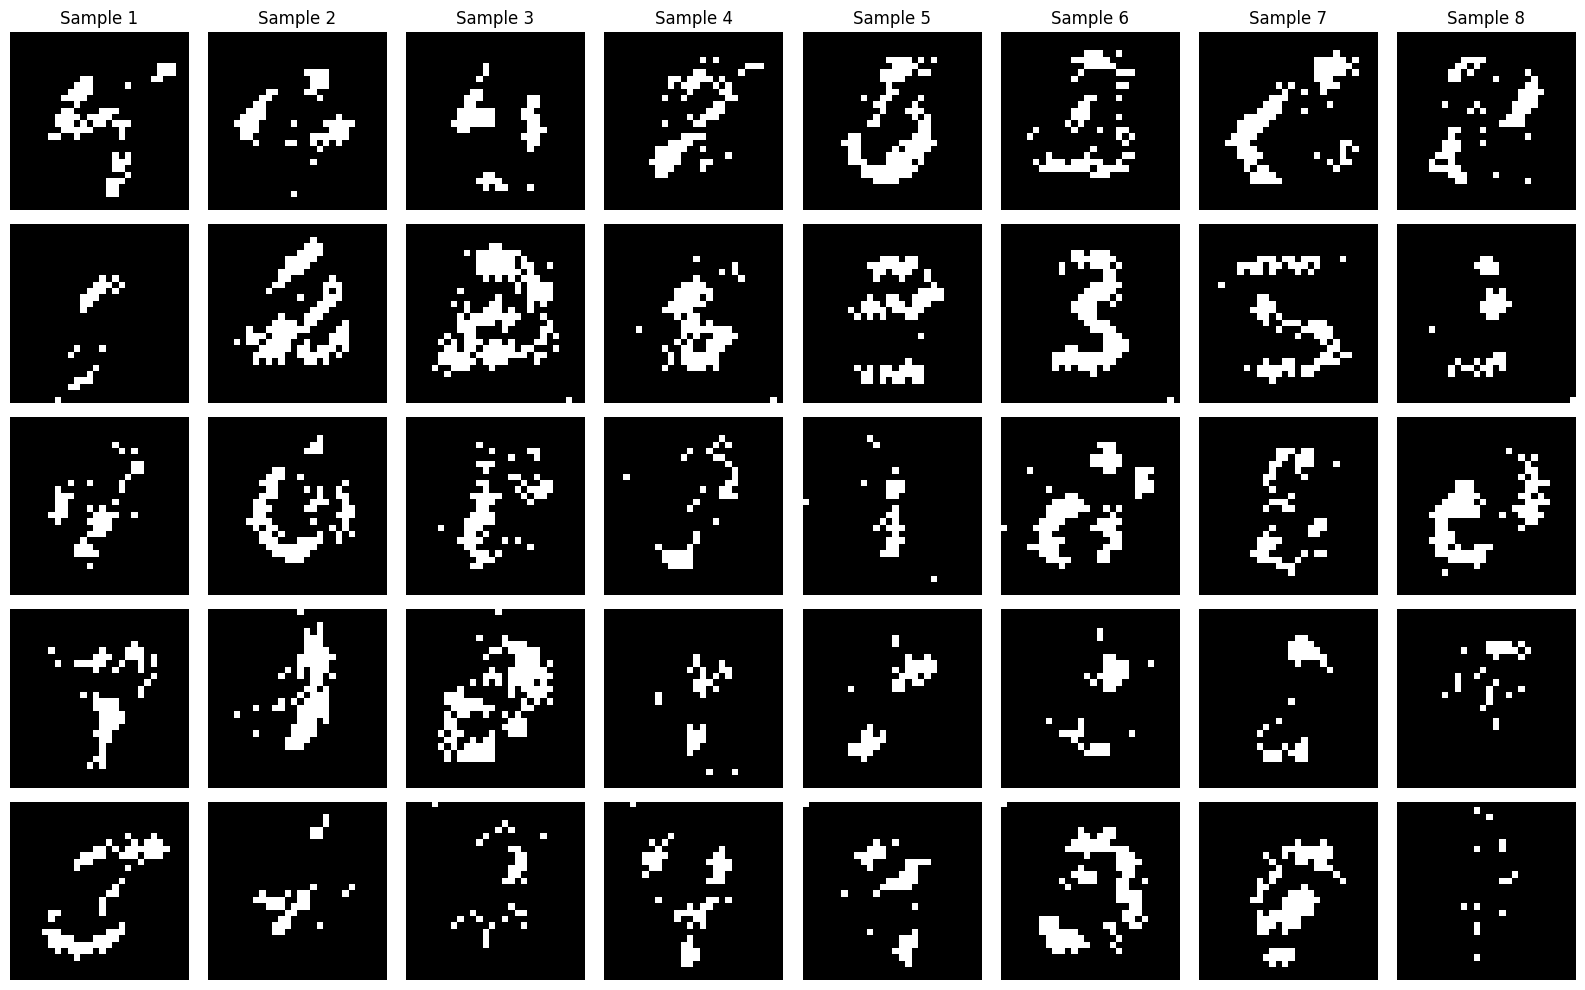

P1_NADE: Mean log p(x) on test set = -18.4207
P2_NADE: Mean log p(x) on test set = -18.4207
P3_NADE: Mean log p(x) on test set = -18.4207
P4_NADE: Mean log p(x) on test set = -18.4207
P5_NADE: Mean log p(x) on test set = -18.4207


In [37]:
with torch.no_grad():
    # Load all permuted NADE models
    nade_models = []
    model_names = ['P1_NADE', 'P2_NADE', 'P3_NADE', 'P4_NADE', 'P5_NADE']
    for name in model_names:
        model = torch.load(f'{name}.model')
        model.eval()
        nade_models.append(model)

    # Generate 8 samples for each model
    num_samples = 8
    fig, axes = plt.subplots(len(nade_models), num_samples, figsize=(num_samples*2, len(nade_models)*2))
    for i, model in enumerate(nade_models):
        samples = model.sample(num_samples)
        samples = samples.cpu().numpy().reshape(-1, 28, 28)
        for j in range(num_samples):
            axes[i, j].imshow(samples[j], cmap='gray')
            axes[i, j].axis('off')
            if i == 0:
                axes[i, j].set_title(f"Sample {j+1}")
        axes[i, 0].set_ylabel(model_names[i], rotation=0, labelpad=40, fontsize=12)

    plt.tight_layout()
    plt.show()

    # Calculate p(x) for the test dataset for each model
    px_results = {}
    for i, model in enumerate(nade_models):
        px_list = []
        for batch in testing_loader:
            x, _ = batch
            x = x.view(x.size(0), -1).to('cuda')
            px, _ = model.evalP(x)
            px_list.append(px.cpu())
        px_all = torch.cat(px_list)
        px_results[model_names[i]] = px_all

    # Print mean log p(x) for each model
    for name in model_names:
        mean_log_px = torch.log(px_results[name] + 1e-8).mean().item()
        print(f"{name}: Mean log p(x) on test set = {mean_log_px:.4f}")

Cualitativamente, la mejor permutación es la 2, mientras que en términos de función de costo, la mejor es la 3, aunque la mayoría están bastante cerca. Al observar estos resultados, es posible que las redes hayan estado sobreentrenadas.